In [1]:
import numpy
import AILibs

dt = 1.0/250.0

num_samples = 1000
        
#  system dynamics
#  state = [x, x_dot, theta, theta_dot]

A = [[ 1.0,        0.003675,  0.0,        0.0      ],
    [-0.0,        0.838078,  0.0,       -0.0      ],
    [ 0.0,       -0.0,        1.0,        0.003698],
 [ 0.0,       -0.0,       -0.0,        0.860136]]

B = [[ 0.0,        0.0      ],
    [ 0.509101,  0.0      ],
    [ 0.0,        0.0      ],
    [ 0.0,       11.300163]]

A = numpy.array(A)  
B = numpy.array(B)



#Q = numpy.diag([1.0, 0.0, 1.0, 0.0])
#R = numpy.diag([10.0, 100.0])  
#controller = AILibs.LQRIDUDiscrete(A, B, Q, R, 0.0001)

Q = numpy.diag([1.0, 0.0, 1.0, 0.0])
R = numpy.diag([0.1, 1.0])  
controller = AILibs.LQRDiscrete(A, B, Q, R)


print("k = ", controller.k)     
#print("ku = ", controller.ku)

# print as C arrays
def numpy_to_c_array(name, mat):
    mat = numpy.atleast_2d(mat)
    rows, cols = mat.shape
    print(f"const float {name}[{rows * cols}] = {{")
    for i in range(rows):
        row_str = ", ".join(f"{mat[i, j]:.6f}f" for j in range(cols))
        comma = "," if i < rows - 1 else ""
        print(f"    {row_str}{comma}")
    print("};")
    print()

print("\n\n")
numpy_to_c_array("lqr_k", controller.k)
#numpy_to_c_array("lqr_ku", controller.ku)
    


k =  [[ 3.10990507e+00  6.55047354e-02  1.15956000e-15  1.18388474e-18]
 [ 1.64962986e-15 -6.51022437e-19  9.11381631e-01  1.62632772e-02]]



const float lqr_k[8] = {
    3.109905f, 0.065505f, 0.000000f, 0.000000f,
    0.000000f, -0.000000f, 0.911382f, 0.016263f
};



In [2]:
ds = AILibs.DynamicalSystemDiscrete(A, B, None)


x = ds.reset()

# 1m distance
d = 1.0

# 90 degrees
a = 90*numpy.pi/180.0

# desired states
xr_a = numpy.array([0.0, 0.0, 0.0, 0.0])
xr_b = numpy.array([d, 0.0, 0.0, 0.0])
xr_c = numpy.array([0.0, 0.0, a, 0.0])
xr_d = numpy.array([d, 0.0, a, 0.0])

# time step
t_result = []

# control inputs
u_result = []

# desired states
xr_result = []

# actual states
x_result = []

u = numpy.zeros((B.shape[1], 1))

for n in range(num_samples):

    # add zero state between different reference states
    
    if n < num_samples/5:
        xr = xr_a
    elif n < 2*num_samples/5:
        xr = xr_b
    elif n < 3*num_samples/5:
        xr = xr_a
    elif n < 4*num_samples/5:
        xr = xr_c
    else:
        xr = xr_d

    xr = numpy.expand_dims(xr, axis=1)

   

    #u = controller.forward(xr, x, u)
    u = controller.forward(xr, x)
    
    x, _ = ds.forward_state(u)

    t_result.append(n*dt)
    u_result.append(u)
    xr_result.append(xr)
    x_result.append(x)


t_result = numpy.array(t_result)
u_result = numpy.array(u_result)
xr_result = numpy.array(xr_result)
x_result = numpy.array(x_result)

print("done")

done


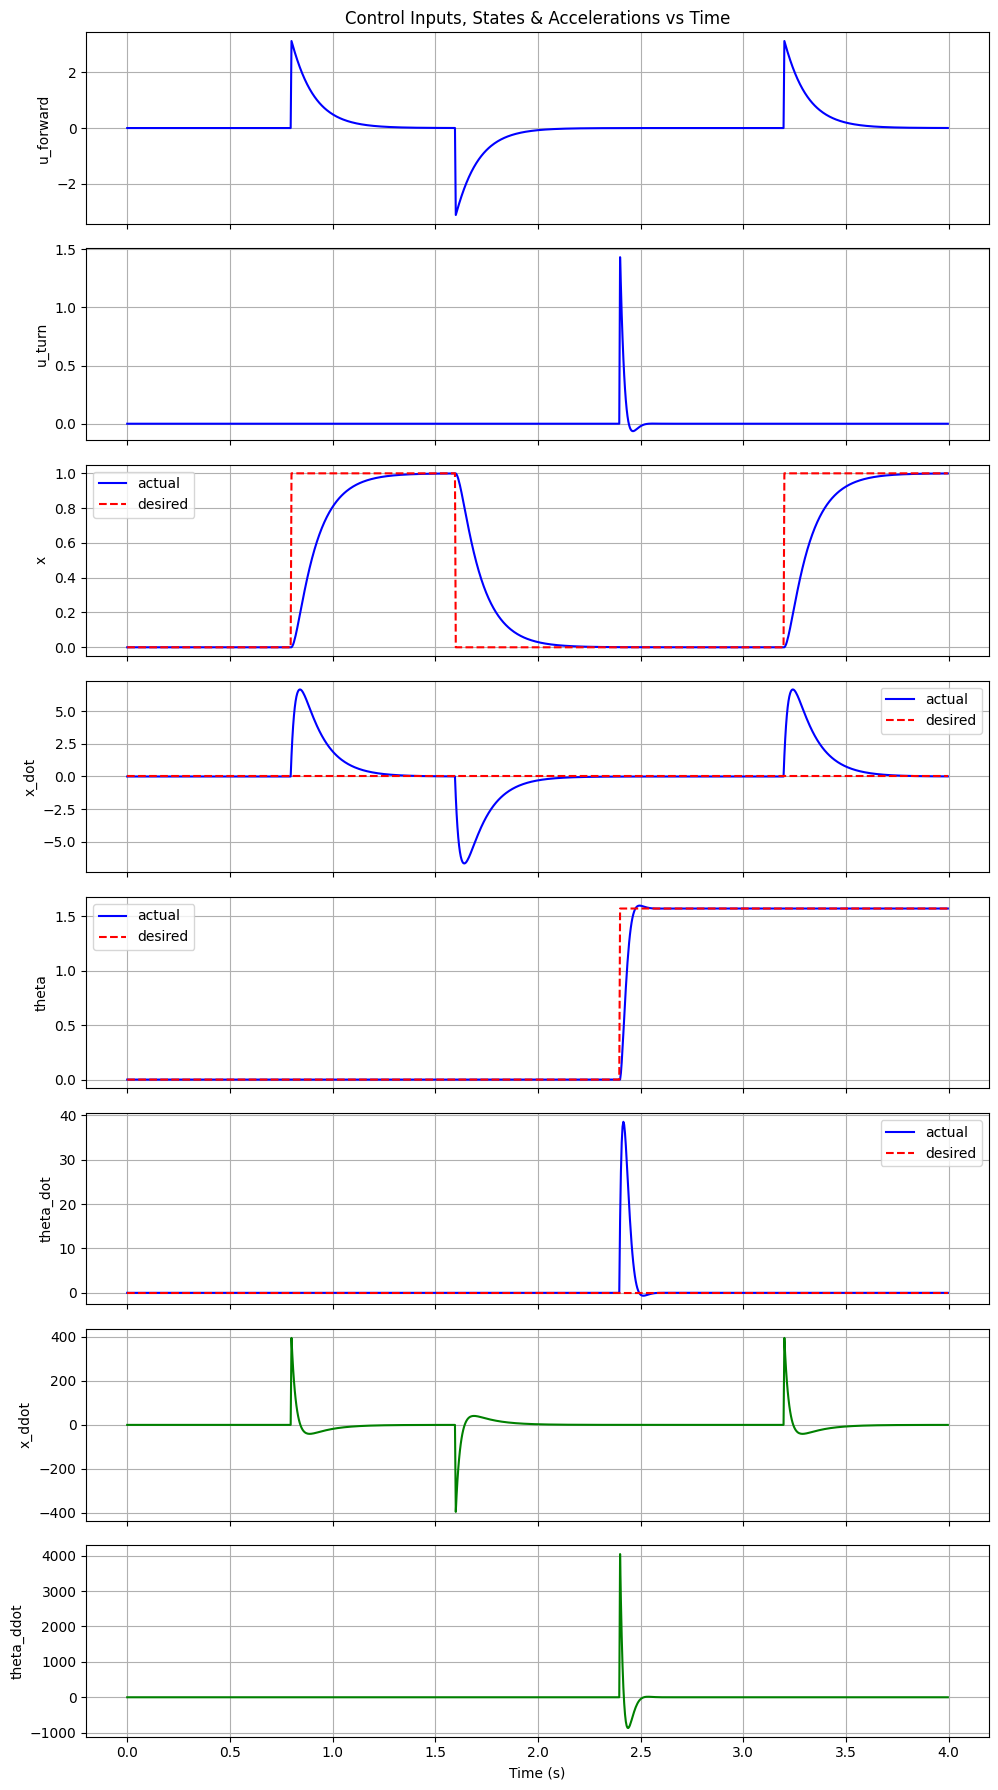

In [3]:
import matplotlib.pyplot as plt

control_labels  = ['u_forward', 'u_turn']
state_labels    = ['x', 'x_dot', 'theta', 'theta_dot']
accel_labels    = ['x_ddot', 'theta_ddot']

# compute accelerations from velocity finite differences
x_dot = x_result[:, 1]
theta_dot = x_result[:, 3]

x_ddot = numpy.zeros_like(x_dot)
theta_ddot = numpy.zeros_like(theta_dot)
x_ddot[1:] = (x_dot[1:] - x_dot[:-1]) / dt
theta_ddot[1:] = (theta_dot[1:] - theta_dot[:-1]) / dt

fig, axes = plt.subplots(8, 1, figsize=(10, 18), sharex=True)

for i in range(2):
    axes[i].plot(t_result, u_result[:, i, 0], color='blue')
    axes[i].set_ylabel(control_labels[i])
    axes[i].grid()

for i in range(4):
    axes[i+2].plot(t_result, x_result[:, i], color='blue', label='actual')
    axes[i+2].plot(t_result, xr_result[:, i, 0], color='red', linestyle='dashed', label='desired')
    axes[i+2].set_ylabel(state_labels[i])
    axes[i+2].legend()
    axes[i+2].grid()

axes[6].plot(t_result, x_ddot, color='green')
axes[6].set_ylabel(accel_labels[0])
axes[6].grid()

axes[7].plot(t_result, theta_ddot, color='green')
axes[7].set_ylabel(accel_labels[1])
axes[7].grid()

axes[-1].set_xlabel('Time (s)')
axes[0].set_title('Control Inputs, States & Accelerations vs Time')
plt.tight_layout()
plt.show()